# Local Multimodal LangChain Agent with Ollama

This notebook builds a small LangChain agent that runs against a local Ollama multimodal model. It uses `qwen3.6:latest` by default and sends both text and an image to the model.

## 0. Install Python dependencies

In [1]:
import sys

%pip install -U -q langchain langchain-ollama langchain-mcp-adapters fastmcp mcp pillow numpy tensorflow shap matplotlib opencv-python-headless chromadb sentence-transformers langchain-chroma langchain-huggingface


Note: you may need to restart the kernel to use updated packages.


## 1. Ollama setup check

Before running the model cells, make sure Ollama is installed, the server is running, and the model has been pulled:

```bash
ollama serve
ollama pull qwen3.6:latest
```

In [2]:
from __future__ import annotations

import json
import shutil
import subprocess
import urllib.error
import urllib.request


MODEL_NAME = "qwen3.6:latest"
OLLAMA_BASE_URL = "http://localhost:11434"


def check_ollama(model_name: str = MODEL_NAME, base_url: str = OLLAMA_BASE_URL) -> list[str]:
    """Return actionable Ollama setup issues. An empty list means the setup looks ready."""
    issues: list[str] = []

    if shutil.which("ollama") is None:
        issues.append("Ollama CLI was not found on PATH. Install it from https://ollama.com/download.")
        return issues

    try:
        version = subprocess.run(["ollama", "--version"], capture_output=True, text=True, timeout=10)
        print(version.stdout.strip() or version.stderr.strip())
    except Exception as exc:
        issues.append(f"Could not run `ollama --version`: {exc}")

    try:
        with urllib.request.urlopen(f"{base_url}/api/tags", timeout=5) as response:
            tags_payload = json.loads(response.read().decode("utf-8"))
    except urllib.error.URLError as exc:
        issues.append(f"Ollama server is not reachable at {base_url}. Start it with `ollama serve`. Details: {exc}")
        return issues

    installed_models = {model.get("name", "") for model in tags_payload.get("models", [])}
    if model_name not in installed_models:
        issues.append(f"Model `{model_name}` is not installed. Pull it with `ollama pull {model_name}`.")

    return issues


ollama_issues = check_ollama()
if ollama_issues:
    raise RuntimeError("\n".join(ollama_issues))

print(f"Ollama is ready with {MODEL_NAME}.")

ollama version is 0.21.2
Ollama is ready with qwen3.6:latest.


## 2. Imports and user inputs

In [3]:
import base64
import os
import mimetypes
import sys
from contextlib import asynccontextmanager
from pathlib import Path

from IPython.display import Markdown, display
from langchain.agents import create_agent
import langchain_mcp_adapters.sessions as mcp_sessions
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_ollama import ChatOllama
from mcp.client.stdio import stdio_client as mcp_stdio_client
from PIL import Image


# Edit these values for your local image and question.
IMAGE_PATH = "../datasets/plant-diseases/test/test/AppleCedarRust1.JPG"
QUESTION = "This is a picture of a leaf from my plant. Can you help me understand what is going on? tell me if it has a disease and what is the name of the plant. Give me advice to take care of it."

# qwen3.6:latest is multimodal in Ollama, but it is a large local model.
MODEL_NAME = "qwen3.6:latest"
MCP_SERVER_PATH = Path.cwd() / "plant_disease_mcp_server.py"


@asynccontextmanager
async def notebook_safe_stdio_client(server):
    with open(os.devnull, "w") as errlog:
        async with mcp_stdio_client(server, errlog=errlog) as streams:
            yield streams


mcp_sessions.stdio_client = notebook_safe_stdio_client


def display_model_content(content) -> None:
    """Render common LangChain text responses in notebooks."""
    if isinstance(content, str):
        display(Markdown(content))
        return
    if isinstance(content, list):
        text_parts = []
        image_count = 0
        for block in content:
            if isinstance(block, dict) and block.get("type") == "text":
                text_parts.append(block.get("text", ""))
            elif isinstance(block, dict) and block.get("type") == "image":
                image_count += 1
            elif isinstance(block, str):
                text_parts.append(block)
        if text_parts:
            display(Markdown("\n\n".join(part for part in text_parts if part)))
        if image_count:
            display(Markdown(f"Returned {image_count} image content block(s)."))
        return
    display(content)


## 3. Image loading helpers

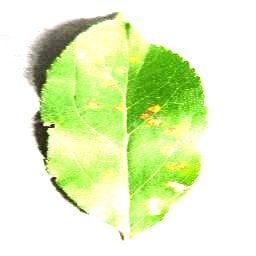

Path: /work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG
Size: 256 x 256 px
Mode: RGB


In [4]:
SUPPORTED_IMAGE_TYPES = {".jpg", ".jpeg", ".png", ".gif", ".webp", ".bmp"}


def resolve_image_path(image_path: str | Path) -> Path:
    raw_path = Path(image_path).expanduser()
    candidates = [raw_path]

    if not raw_path.is_absolute():
        notebook_dir = Path.cwd()
        project_dir = notebook_dir.parent
        workspace_dir = project_dir.parent
        candidates.extend(
            [
                notebook_dir / raw_path,
                project_dir / raw_path,
                project_dir / "datasets" / raw_path,
                workspace_dir / raw_path,
            ]
        )

    for candidate in candidates:
        path = candidate.resolve()
        if path.exists():
            break
    else:
        checked = "\n".join(f"- {candidate.resolve()}" for candidate in candidates)
        raise FileNotFoundError(f"Image file does not exist. Checked:\n{checked}")

    if path.suffix.lower() not in SUPPORTED_IMAGE_TYPES:
        raise ValueError(f"Unsupported image extension `{path.suffix}`. Use one of: {sorted(SUPPORTED_IMAGE_TYPES)}")
    return path


def image_to_base64(image_path: str | Path) -> tuple[str, str, Path]:
    path = resolve_image_path(image_path)
    mime_type = mimetypes.guess_type(path.name)[0] or "image/jpeg"
    image_b64 = base64.b64encode(path.read_bytes()).decode("utf-8")
    return image_b64, mime_type, path


def preview_image(image_path: str | Path) -> Path:
    path = resolve_image_path(image_path)
    image = Image.open(path)
    display(image)
    print(f"Path: {path}")
    print(f"Size: {image.width} x {image.height} px")
    print(f"Mode: {image.mode}")
    return path


image_path = preview_image(IMAGE_PATH)
image_b64, image_mime_type, image_path = image_to_base64(image_path)

## 4. Direct multimodal model call

This first call verifies that the local model can read the image before we wrap it in an agent.

In [5]:
llm = ChatOllama(
    model=MODEL_NAME,
    temperature=0.2,
    base_url=OLLAMA_BASE_URL,
)

multimodal_message = {
    "role": "user",
    "content": [
        {"type": "text", "text": QUESTION},
        {"type": "image", "base64": image_b64, "mime_type": image_mime_type},
    ],
}

direct_response = llm.invoke([multimodal_message])
display_model_content(direct_response.content)

Based on the visual evidence in the photo, here is an analysis of your plant's condition.

### 1. What is the plant?
It is difficult to be 100% certain without seeing the whole plant, but based on the leaf shape (ovate with a pointed tip), the serrated (saw-toothed) edges, and the vein pattern, this leaf looks like it belongs to one of the following:
*   **A Rose bush** (this is a leaflet from a compound leaf).
*   **A Fruit Tree** such as an **Apple**, **Pear**, or **Crabapple**.
*   **A Cherry tree.**

### 2. What is the disease?
The leaf is showing signs of **Rust Fungus**.

*   **The Evidence:** The distinct bright orange and yellow spots scattered across the leaf are the classic symptoms of rust. Rust fungi typically start as small, bright orange or yellow spots on the upper surface of the leaf.
*   **The Yellowing:** The general yellowing (chlorosis) of the leaf tissue, especially on the left side where it looks bleached, is likely a reaction to the fungal infection. The fungus is stealing nutrients from the leaf, causing it to lose its green color.
*   **Alternative Possibility:** The bleached, dusty-looking area on the left could also indicate **Spider Mites**. Spider mites suck the chlorophyll out of the leaf, creating tiny yellow/white dots that merge into large pale patches. It is possible to have both rust and mites at the same time.

### 3. Advice on how to take care of it

**Immediate Actions:**
*   **Remove Infected Leaves:** Pick off the worst-looking leaves (like the one in the picture) and throw them in the trash. **Do not compost them**, as the fungus can survive and spread.
*   **Clean Up:** Rake up any fallen leaves around the base of the plant, as the fungus can overwinter in them.

**Prevention and Treatment:**
*   **Watering Habits:** Rust fungi thrive in moisture. Try to water the plant at the **base** (the soil), not over the top of the leaves. Wet leaves encourage the fungus to grow.
*   **Air Circulation:** If the plant is crowded, prune some branches to let air flow through. Rust spreads easily in stagnant, humid air.
*   **Fungicide:** If the problem persists, you can buy a fungicide labeled for "Rust" (often containing sulfur or copper). Apply it according to the instructions on the bottle.
*   **Check for Mites:** Look closely at the underside of the leaves. If you see tiny moving dots or fine webbing, you have spider mites. You can wash them off with a strong stream of water or use Neem oil.

**Nutrient Check:**
If the yellowing continues even after treating the fungus, your plant might have **Iron Chlorosis** (a nutrient deficiency). This happens when the soil is too alkaline (high pH) and the plant can't absorb iron. You can test your soil pH or use a chelated iron supplement.

## 5. LangChain agent with FastMCP CNN and retrieval tools

The plant disease classifier and plant disease retrieval tool now run behind a local FastMCP server. The server loads the already-trained `.keras` models from this notebook directory, can optionally return a SHAP explanation image as MCP image content, and can retrieve supporting information from the local Chroma vector database.


In [6]:
if not MCP_SERVER_PATH.exists():
    raise FileNotFoundError(f"MCP server file not found: {MCP_SERVER_PATH}")

mcp_client = MultiServerMCPClient(
    {
        "plant_disease": {
            "transport": "stdio",
            "command": sys.executable,
            "args": [str(MCP_SERVER_PATH)],
            "cwd": str(MCP_SERVER_PATH.parent),
        }
    }
)

mcp_tools = await mcp_client.get_tools()
print("Loaded MCP tools:", [tool.name for tool in mcp_tools])

agent = create_agent(
    model=llm,
    tools=mcp_tools,
    system_prompt=(
        "You are a concise multimodal plant owner assistant. "
        "You help plant owners taking care of their plants. "
        "Use the predict_plant_disease tool when the user asks for plant disease classification, "
        "diagnosis, or likely disease labels from a local leaf image path. "
        "After predicting a disease, call retrieve_plant_disease_info with the predicted plant and disease "
        "when giving symptoms, prevention, care, or management advice. "
        "Also use retrieve_plant_disease_info for text-only plant disease questions. "
        "Ground plant disease advice in retrieved results and mention source titles or URLs when available. "
        "If retrieval returns no useful support, say that the local resources did not contain enough information. "
        "If the user asks for a visual explanation, SHAP explanation, or why the model predicted a class, "
        "call predict_plant_disease with include_shap=true. "
        "Base visual answers on the image content supplied by the user."
    ),
    debug=True,
)


Loaded MCP tools: ['predict_plant_disease', 'retrieve_plant_disease_info']


## 6. Run the agent with text and image input

In [7]:
agent_message = {
    "role": "user",
    "content": [
        {
            "type": "text",
            "text": (
                f"Image path: {image_path}\n\n"
                f"Question: {QUESTION}\n\n"
                "Answer using the image. If useful, call the predict_plant_disease tool. "
                "Use retrieve_plant_disease_info for supporting plant disease care and management information. "
                "Only request SHAP output if a visual model explanation is needed."
            ),
        },
        {"type": "image", "base64": image_b64, "mime_type": image_mime_type},
    ],
}

agent_result = await agent.ainvoke({"messages": [agent_message]})
final_message = agent_result["messages"][-1]
display_model_content(final_message.content)


[values] {'messages': [HumanMessage(content=[{'type': 'text', 'text': 'Image path: /work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG\n\nQuestion: This is a picture of a leaf from my plant. Can you help me understand what is going on? tell me if it has a disease and what is the name of the plant. Give me advice to take care of it.\n\nAnswer using the image. If useful, call the predict_plant_disease tool. Use retrieve_plant_disease_info for supporting plant disease care and management information. Only request SHAP output if a visual model explanation is needed.'}, {'type': 'image', 'base64': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCAEAAQADASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY

[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.6:latest', 'created_at': '2026-05-25T15:12:51.200184755Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5917639661, 'load_duration': 126494223, 'prompt_eval_count': 946, 'prompt_eval_duration': 1311433280, 'eval_count': 224, 'eval_duration': 4367941593, 'logprobs': None, 'model_name': 'qwen3.6:latest', 'model_provider': 'ollama'}, id='lc_run--019e5fb2-0edf-7e30-8ce6-de2ebdd2a2f8-0', tool_calls=[{'name': 'predict_plant_disease', 'args': {'image_path': '/work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG', 'top_k': 3}, 'id': 'ad5d12eb-0608-4786-a3c3-0df8714b2f67', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 946, 'output_tokens': 224, 'total_tokens': 1170})]}}
[values] {'messages': [HumanMessage(content=[{'type': 'text', 'text': 'Image path: /work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG\n\

[updates] {'tools': {'messages': [ToolMessage(content=[{'type': 'text', 'text': '{\n  "model": "MobileNetV2",\n  "image": "/work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG",\n  "top_class_index": 2,\n  "top_class": "Apple___Cedar_apple_rust",\n  "top_confidence": 0.9997640252113342,\n  "predictions": [\n    {\n      "rank": 1,\n      "class": "Apple___Cedar_apple_rust",\n      "confidence": 0.9997640252113342\n    },\n    {\n      "rank": 2,\n      "class": "Blueberry___healthy",\n      "confidence": 0.00016237648378591985\n    },\n    {\n      "rank": 3,\n      "class": "Apple___Apple_scab",\n      "confidence": 6.369040784193203e-05\n    }\n  ],\n  "shap": {\n    "included": false\n  }\n}', 'id': 'lc_fe82c127-da34-4c8a-8b6f-44172d42556d'}], name='predict_plant_disease', id='8490e07a-40f5-4b34-b0e7-e329e698bb1b', tool_call_id='ad5d12eb-0608-4786-a3c3-0df8714b2f67', artifact={'structured_content': {'model': 'MobileNetV2', 'image': '/work/AAI_project/datasets/plan

[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.6:latest', 'created_at': '2026-05-25T15:13:08.179800039Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4420666753, 'load_duration': 129961390, 'prompt_eval_count': 1306, 'prompt_eval_duration': 1112281988, 'eval_count': 152, 'eval_duration': 3086071499, 'logprobs': None, 'model_name': 'qwen3.6:latest', 'model_provider': 'ollama'}, id='lc_run--019e5fb2-570c-7b12-a139-e7e275510cfe-0', tool_calls=[{'name': 'retrieve_plant_disease_info', 'args': {'query': 'Apple Cedar Rust symptoms prevention care', 'top_k': 3}, 'id': 'b0d82f7b-87df-47f7-878e-e6c939fadf9b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1306, 'output_tokens': 152, 'total_tokens': 1458})]}}
[values] {'messages': [HumanMessage(content=[{'type': 'text', 'text': 'Image path: /work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG\n\nQuestion: This is a pictur

[updates] {'tools': {'messages': [ToolMessage(content=[{'type': 'text', 'text': '{\n  "query": "Apple Cedar Rust symptoms prevention care",\n  "result_count": 3,\n  "results": [\n    {\n      "rank": 1,\n      "score": 0.586888313293457,\n      "content": "## Quick facts\\n\\n- Cedar-apple rust and related rust fungi need plants from two plant families to complete their life cycle.\\n\\n- These fungi rarely cause serious damage to their hosts and do not require management in most cases.\\n\\n- This disease can cause damage to leaves and fruit of very susceptible apple varieties but is only a minor problem on resistant or partially resistant trees.\\n\\n- Do not plant eastern red cedar and juniper within a few hundred yards of apples, hawthorns, and other plants from the Rosaceae family.\\n\\n- Disease-resistant varieties are available for some plants.",\n      "title": "Cedar-apple rust and related rust diseases | UMN Extension",\n      "labels": "Apple cedar apple rust",\n      "sourc

[updates] {'model': {'messages': [AIMessage(content='Based on the image analysis, your plant is an **Apple** tree, and it is showing strong signs of **Cedar-apple Rust**.\n\n### What is happening?\nThe orange spots on your leaf are characteristic of Cedar-apple Rust. This disease is caused by a fungus that requires two different types of plants to complete its life cycle: an apple (or crabapple) tree and an eastern red cedar or juniper.\n\n### Care and Management Advice\nAccording to the University of Minnesota Extension, here is how you can manage this issue:\n\n*   **Assess the Severity:** This fungus rarely causes serious damage to the apple tree itself. It is generally considered a minor problem unless you have a very susceptible variety.\n*   **Pruning:** If you notice infected twigs or branches on your tree, you can prune and remove them to help reduce the spread.\n*   **Planting Considerations:** If you are planning new plantings, try to avoid planting eastern red cedars or juni

Based on the image analysis, your plant is an **Apple** tree, and it is showing strong signs of **Cedar-apple Rust**.

### What is happening?
The orange spots on your leaf are characteristic of Cedar-apple Rust. This disease is caused by a fungus that requires two different types of plants to complete its life cycle: an apple (or crabapple) tree and an eastern red cedar or juniper.

### Care and Management Advice
According to the University of Minnesota Extension, here is how you can manage this issue:

*   **Assess the Severity:** This fungus rarely causes serious damage to the apple tree itself. It is generally considered a minor problem unless you have a very susceptible variety.
*   **Pruning:** If you notice infected twigs or branches on your tree, you can prune and remove them to help reduce the spread.
*   **Planting Considerations:** If you are planning new plantings, try to avoid planting eastern red cedars or junipers within a few hundred yards of your apple trees.
*   **Resistant Varieties:** If you are replacing your tree or planting a new one, look for rust-resistant varieties. Some resistant apple and crabapple varieties include **Fireside**, **Freedom**, **Liberty**, and **Nova**.

For more detailed information, you can visit the [Cedar-apple rust and related rust diseases guide from UMN Extension](https://extension.umn.edu/plant-diseases/cedar-apple-rust).

## 7. Inspect agent steps

In [8]:
import json


def shorten(value, limit=1200):
    text = value if isinstance(value, str) else json.dumps(value, indent=2, default=str)
    return text if len(text) <= limit else text[:limit] + "\n... [truncated]"


def print_content_blocks(content):
    if isinstance(content, list):
        for block_index, block in enumerate(content, start=1):
            if isinstance(block, dict):
                block_type = block.get("type", "dict")
                print(f"  Content block {block_index}: {block_type}")
                if block_type == "text":
                    print(shorten(block.get("text", "")))
                elif block_type == "image":
                    print(f"  [image content: {block.get('mime_type') or block.get('mimeType') or 'image'}]")
                else:
                    print(shorten(block))
            else:
                print(f"  Content block {block_index}: {type(block).__name__}")
                print(shorten(block))
    else:
        print(shorten(content))


for index, message in enumerate(agent_result["messages"], start=1):
    message_type = getattr(message, "type", type(message).__name__)
    message_name = getattr(message, "name", None)
    print(f"\n--- Step {index}: {message_type}{f' | name={message_name}' if message_name else ''} ---")

    tool_calls = getattr(message, "tool_calls", None) or []
    if tool_calls:
        print("Tool calls:")
        for call_index, call in enumerate(tool_calls, start=1):
            print(f"  {call_index}. {call.get('name')} id={call.get('id')}")
            print(shorten(call.get("args", {})))

    invalid_tool_calls = getattr(message, "invalid_tool_calls", None) or []
    if invalid_tool_calls:
        print("Invalid tool calls:")
        print(shorten(invalid_tool_calls))

    tool_call_id = getattr(message, "tool_call_id", None)
    if tool_call_id:
        print(f"Tool call id: {tool_call_id}")

    content = getattr(message, "content", message)
    print("Content:")
    print_content_blocks(content)

    response_metadata = getattr(message, "response_metadata", None)
    if response_metadata:
        print("Response metadata:")
        print(shorten(response_metadata, limit=800))

    usage_metadata = getattr(message, "usage_metadata", None)
    if usage_metadata:
        print("Usage metadata:")
        print(shorten(usage_metadata, limit=800))



--- Step 1: human ---
Content:
  Content block 1: text
Image path: /work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG

Question: This is a picture of a leaf from my plant. Can you help me understand what is going on? tell me if it has a disease and what is the name of the plant. Give me advice to take care of it.

Answer using the image. If useful, call the predict_plant_disease tool. Use retrieve_plant_disease_info for supporting plant disease care and management information. Only request SHAP output if a visual model explanation is needed.
  Content block 2: image
  [image content: image/jpeg]

--- Step 2: ai ---
Tool calls:
  1. predict_plant_disease id=ad5d12eb-0608-4786-a3c3-0df8714b2f67
{
  "image_path": "/work/AAI_project/datasets/plant-diseases/test/test/AppleCedarRust1.JPG",
  "top_k": 3
}
Content:

Response metadata:
{
  "model": "qwen3.6:latest",
  "created_at": "2026-05-25T15:12:51.200184755Z",
  "done": true,
  "done_reason": "stop",
  "total_duration